# TSNE - Projet Final

## Objectif
Ce notebook implemente la partie TSNE du projet collaboratif.

## Etat actuel
- Initialisation de l'environnement
- Chargement des donnees
- Inspection rapide avant preprocessing


In [1]:
# Imports essentiels
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE  # Remplacement de PCA par TSNE
from sklearn.preprocessing import StandardScaler
import seaborn as sns # Optionnel, pour de plus beaux graphiques

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

In [2]:
# Parametres de base
RANDOM_STATE = 42

PROJECT_ROOT = Path('..')
DATA_PATH = PROJECT_ROOT / 'data' / 'city_lifestyle_dataset.csv'
OUTPUT_DIR = PROJECT_ROOT / 'outputs'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f'Data path: {DATA_PATH}')
print(f'Output dir: {OUTPUT_DIR}')


Data path: ../data/city_lifestyle_dataset.csv
Output dir: ../outputs


## 1. Chargement et inspection rapide des donnees

Verification rapide avant la reduction de dimension:
- dimensions du dataset
- type des colonnes
- valeurs manquantes


In [4]:
# Chargement du dataset
if not DATA_PATH.exists():
    raise FileNotFoundError(f'Dataset introuvable: {DATA_PATH.resolve()}')

df = pd.read_csv(DATA_PATH)
print(f'Shape: {df.shape}')
df.head()


Shape: (300, 10)


,city_name,country,population_density,avg_income,internet_penetration,avg_rent,air_quality_index,public_transport_score,happiness_score,green_space_ratio
0,Old Vista,Europe,2775,3850,86.4,1310,43,52.0,8.5,23.8
1,Beachport,Europe,3861,3700,78.1,1330,42,62.8,8.1,33.1
2,Valleyborough,Europe,2562,4310,80.1,1330,39,73.2,8.5,40.2
3,City,Europe,3192,3970,81.2,1480,60,49.2,8.5,43.6
4,Falls,Europe,3496,4320,100.0,1510,64,93.7,8.5,42.5


In [5]:
# Inspection rapide
print('\nTypes de colonnes:')
print(df.dtypes)

missing = df.isna().sum()
print('\nValeurs manquantes par colonne:')
print(missing[missing > 0] if (missing > 0).any() else 'Aucune valeur manquante')



Types de colonnes:
city_name                  object
country                    object
population_density          int64
avg_income                  int64
internet_penetration      float64
avg_rent                    int64
air_quality_index           int64
public_transport_score    float64
happiness_score           float64
green_space_ratio         float64
dtype: object

Valeurs manquantes par colonne:
Aucune valeur manquante


## 2. Preprocessing pour t-SNE

PCA fonctionne sur des variables numeriques comparables en echelle.
Dans cette etape, on:
- selectionne les colonnes numeriques
- verifie qu'il n'y a pas de valeurs manquantes sur ces colonnes
- standardise les features avec `StandardScaler`


In [6]:
# Selection des variables numeriques
numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
X = df[numeric_cols].copy()

print(f'Colonnes numeriques ({len(numeric_cols)}): {numeric_cols}')
print(f'Shape de X: {X.shape}')

if X.isna().any().any():
    raise ValueError('Valeurs manquantes detectees dans les colonnes numeriques. Nettoyer avant PCA.')


Colonnes numeriques (8): ['population_density', 'avg_income', 'internet_penetration', 'avg_rent', 'air_quality_index', 'public_transport_score', 'happiness_score', 'green_space_ratio']
Shape de X: (300, 8)


In [7]:
# Standardisation des variables
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=numeric_cols)
X_scaled_df.describe().T[['mean', 'std']].head(10)


,mean,std
population_density,0.000000e+00,1.001671
avg_income,1.421085e-16,1.001671
internet_penetration,6.276461e-16,1.001671
avg_rent,3.552714e-17,1.001671
air_quality_index,-1.184238e-16,1.001671
public_transport_score,8.052818e-16,1.001671
happiness_score,-7.105427e-17,1.001671
green_space_ratio,1.184238e-16,1.001671


## 3. Projection t-SNE

In [8]:
## 3. Projection t-SNE en 2D
# Initialisation de t-SNE
# perplexity: paramètre clé pour t-SNE, à ajuster selon la taille du dataset (ici 30 est standard)
tsne = TSNE(n_components=2, perplexity=30, random_state=RANDOM_STATE, init='pca', learning_rate='auto')

# Application de t-SNE sur les données standardisées
X_tsne = tsne.fit_transform(X_scaled_df)

# Création d'un DataFrame avec les résultats
df_tsne = pd.DataFrame(data=X_tsne, columns=['tsne_1', 'tsne_2'])
df_tsne['city_name'] = df['city_name'] # On garde le nom des villes pour l'analyse

print(f"Dimensions après t-SNE : {df_tsne.shape}")
df_tsne.head()

Dimensions après t-SNE : (300, 3)


,tsne_1,tsne_2,city_name
0,13.304940,2.003719,Old Vista
1,9.172458,0.220417,Beachport
2,14.388122,-5.302523,Valleyborough
3,8.702012,-5.379359,City
4,22.572191,1.124953,Falls


## 4. Visualisation

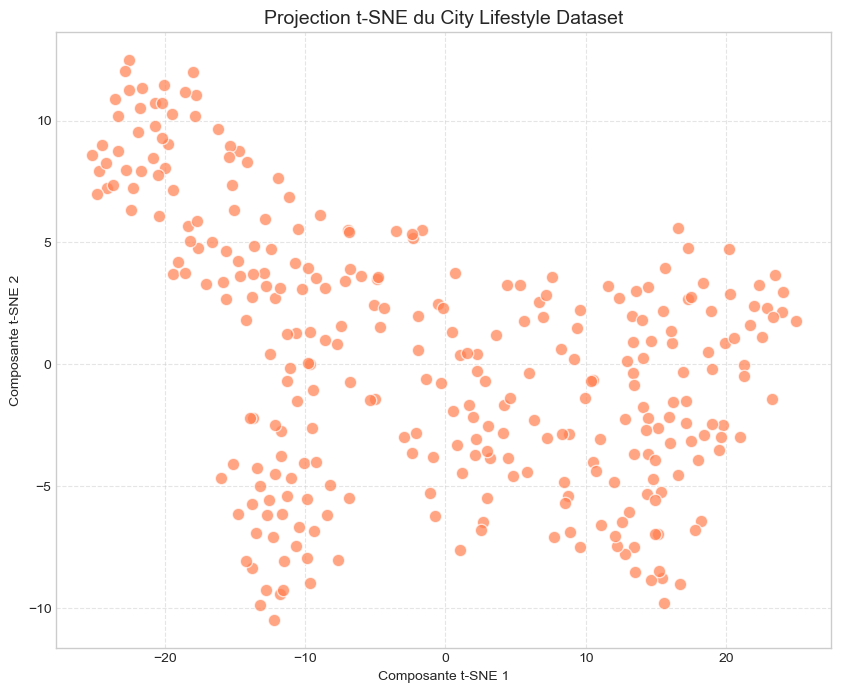

In [9]:
## 4. Visualisation
plt.figure(figsize=(10, 8))
plt.scatter(df_tsne['tsne_1'], df_tsne['tsne_2'], alpha=0.7, c='coral', edgecolors='w', s=80)

plt.title('Projection t-SNE du City Lifestyle Dataset', fontsize=14)
plt.xlabel('Composante t-SNE 1')
plt.ylabel('Composante t-SNE 2')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Observation : On observe sur 2 groupes, plutôt sur la partie gauche du graph, en haut et en bas. La partie droite présente un nuage de points plsu vaste. Cela veut dire que le modèle a réussi à regroupper les villes similaires.

## 5. Export

In [10]:
## 5. Export des données pour comparaison
output_file = OUTPUT_DIR / 'tsne_emb_2d.csv'

# Sauvegarde des 2 composantes uniquement (sans l'index)
df_tsne[['tsne_1', 'tsne_2']].to_csv(output_file, index=False)

print(f"Les données projetées en 2D ont été sauvegardées avec succès ici : {output_file}")

Les données projetées en 2D ont été sauvegardées avec succès ici : ../outputs/tsne_emb_2d.csv
